# Machine Learning in Science - 2025-2026
- Teacher: Alessandro Corbetta [a.corbetta@tue.nl](mailto:a.corbetta@tue.nl)
- Co-teacher: Chiel van der Laan [c.v.d.laan@tue.nl](mailto:c.v.d.laan@tue.nl)

## [25-02-2026] - Ungraded Assignment: Learning the frequency of a pendulum from data

<center>
    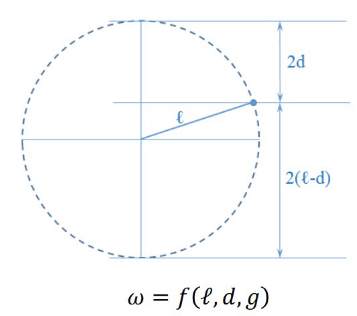
</center>

Define and train a neural network in PyTorch for predicting the period of a pendulum. Your network should consist of (at least) 2 hidden layers. 

**Tasks:**

1. Initialize python (import libraries etc).
1. Import the data (available on canvas as csv, use pandas).
1. Scale the **training data** to ensure dimensional homogeneity and visualize the relation.
1. Define a network with (at least) 2 hidden layers. Remember these 4 steps to success:
   1. construct your model,
   2. define a loss function and optimizer,
   3. implement the training loop,
   4. and tune your hyperparameters (learning rate, network architecture, etc.).
1. Evaluate the accuracy on the **validation set** ( $\neq$ training set!!).
    - Similarly to what we did for the Euclidean distance problem, show plots of $f = 1$ manifolds, as well as comparisons between predictions and the ground truth.
    - What happens when you run the training procedure multiple times? Do you get the same results? Why might this be?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

### Import the data

In [2]:
def load_data(train_fname, test_fname):
    train_set = pd.read_csv(train_fname)
    test_set = pd.read_csv(test_fname)

    return train_set, test_set

In [ ]:
my_training_loc = "pendulum_training.csv"
my_verification_loc = "pendulum_verification.csv"
data_train, data_test = load_data(my_training_loc, my_verification_loc)
data_train.head()

,id,length,drop,grav,omega
0,0,0.077481,0.053892,9.81,10.297085
1,1,2.459308,0.571755,9.81,1.433100
2,2,2.043616,1.798557,9.81,2.122642
3,3,0.173519,0.106935,9.81,6.686397
4,4,1.382322,0.032855,9.81,1.279849


### Render the problem dimensionally homogeneous

Dimensional homogeneity can be achieved in multiple ways. One possible choice is:
- $[\omega] = s^{-1}$
- $x_0 = \sqrt{\frac{g}{l}} \rightarrow^{[\cdot]} s^{-1}$
- $x_1 = \sqrt{\frac{gd}{l^2}} \rightarrow^{[\cdot]} s^{-1}$

Thus, we want to learn the function $f$ such that $\omega = f(x_0, x_1)$.

In [4]:
def make_dim_hom(df):
    df_dim_hom = pd.DataFrame(columns=["x0", "x1", "omega"])
    df_dim_hom["x0"] = np.sqrt(df["grav"] / df["length"])
    df_dim_hom["x1"] = np.sqrt(df["grav"] * df["drop"] / (df["length"] ** 2))
    df_dim_hom["omega"] = df["omega"]

    return df_dim_hom

In [5]:
data_train_dim_hom = make_dim_hom(data_train)
data_test_dim_hom = make_dim_hom(data_test)

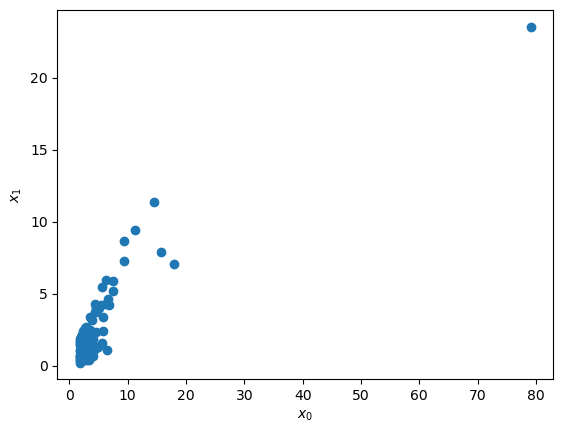

In [ ]:
plt.scatter(data_train_dim_hom['x0'], data_train_dim_hom['x1'])
plt.xlabel("$x_0$")
plt.ylabel("$x_1$")
plt.show()

By dividing the inputs by $\omega$, we produce the $f\left(\frac{x_0}{\omega}, \frac{x_1}{\omega}\right)=1$ contour. Note that this contour line completely defines the physics of this problem.

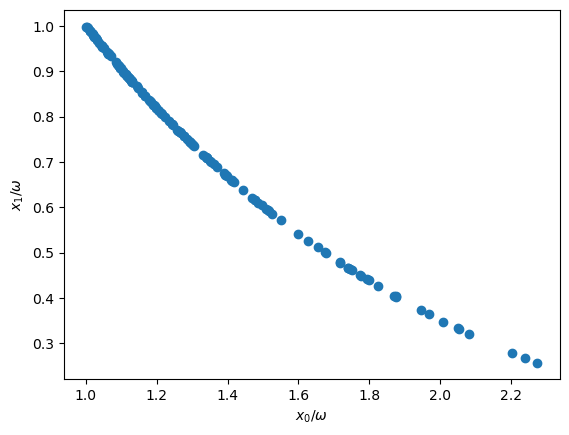

In [ ]:
plt.scatter(
    data_train_dim_hom['x0'] / data_train_dim_hom['omega'],
    data_train_dim_hom['x1'] / data_train_dim_hom['omega'],
)
plt.xlabel("$x_0 / \omega$")
plt.ylabel("$x_1 / \omega$")
plt.show()

### Load the data into our custom `PandasDataset` implementation

In [8]:
def df_to_tensors(df, train_keys, label_key):
    train_data = torch.tensor(df[train_keys].to_numpy(), dtype=torch.float32)
    labels = torch.tensor(df[[label_key]].to_numpy(), dtype=torch.float32)

    return train_data, labels


class PandasData(Dataset):
    def __init__(self, df, train_keys, label_key):
        self.input = torch.tensor(df[train_keys].to_numpy(), dtype=torch.float32)
        self.labels = torch.tensor(df[[label_key]].to_numpy(), dtype=torch.float32)

    def __len__(self):
        return self.input.size()[0]

    def __getitem__(self, index):
        return self.input[index], self.labels[index]

In [9]:
train_dataset = PandasData(data_train_dim_hom, ["x0", "x1"], "omega")

In [10]:
# Prepare the test data
test_input, test_labels = df_to_tensors(data_test_dim_hom, ["x0", "x1"], "omega")

### Define your model

In [11]:
def make_model():
    return nn.Sequential(
        nn.Linear(2, 32, bias=False),
        nn.ReLU(),
        nn.Linear(32, 32, bias=False),
        nn.ReLU(),
        nn.Linear(32, 1, bias=False),
    )

### Implement the training loop and train your model

In [ ]:
def train_model(
    train_data,
    test_input,
    test_labels,
    model,
    loss_fn,
    epochs=10,
    lr=0.01,
    batch_size=1,
    print_every=1,
):

    # Initialize optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_dict = {"train": [], "test": []}

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # We use a `DataLoader` to get batching for free!
    train_data_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False)

    # Print header.
    print(f"Epoch    Train MSE      Test MSE")

    for epoch in range(epochs):
        epoch_loss_sum = 0

        for x_batch, y_batch in train_data_loader:
            # Reset optimizer gradients.
            optimizer.zero_grad()

            # Predict the output
            y_pred = model(x_batch)

            # Compute the loss
            loss = loss_fn(y_pred, y_batch)
            epoch_loss_sum += loss.item()

            # Compute gradients according to newly computed loss.
            loss.backward()

            # Update the model parameters.
            optimizer.step()

        loss_dict["train"].append(epoch_loss_sum / len(train_data_loader))

        with torch.no_grad():
            test_pred = model(test_input)
            test_loss = loss_fn(test_pred, test_labels)
            loss_dict["test"].append(test_loss.item())

        if (epoch + 1) % print_every == 0:
            print(
                f"{epoch+1: <7}  {loss_dict['train'][-1]: <12.6e}  {loss_dict['test'][-1]: .6e}"
            )

    return model, loss_dict

In [ ]:
model = make_model() # Initialize the model
# again notice how we are re-initializing the model here, so that we start training from scratch
loss_fn = nn.MSELoss()

model, loss_dict = train_model(
    train_dataset,
    test_input,
    test_labels,
    model,
    loss_fn,
    epochs=3000,
    lr=5e-5,
    batch_size=32,
    print_every=100,
)

Epoch    Train MSE      Test MSE
100      1.301953e+01   8.265156e+00
200      4.783457e+00   4.397013e+00
300      1.714583e+00   2.110896e+00
400      1.075221e+00   1.201156e+00
500      7.404031e-01   7.678896e-01
600      4.599274e-01   4.575744e-01
700      2.483407e-01   2.347629e-01
800      1.101546e-01   9.608912e-02
900      3.986931e-02   3.060815e-02
1000     1.502009e-02   9.869617e-03
1100     9.160536e-03   6.238727e-03
1200     7.762187e-03   5.672427e-03
1300     6.888658e-03   5.041325e-03
1400     6.072017e-03   4.333843e-03
1500     5.316812e-03   3.676464e-03
1600     4.588303e-03   3.057229e-03
1700     3.963098e-03   2.483698e-03
1800     3.307706e-03   2.056999e-03
1900     2.793052e-03   1.724094e-03
2000     2.328341e-03   1.428786e-03
2100     1.876288e-03   1.147180e-03
2200     1.445405e-03   8.811216e-04
2300     1.054331e-03   6.424630e-04
2400     7.223144e-04   4.412254e-04
2500     4.601394e-04   2.829837e-04
2600     2.712270e-04   1.667830e-04
2700 

In [14]:
def plot_losses(train, test):
    plt.semilogy(train, label="train", marker=".", lw=2)
    plt.semilogy(test, label="test", marker=".", lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()

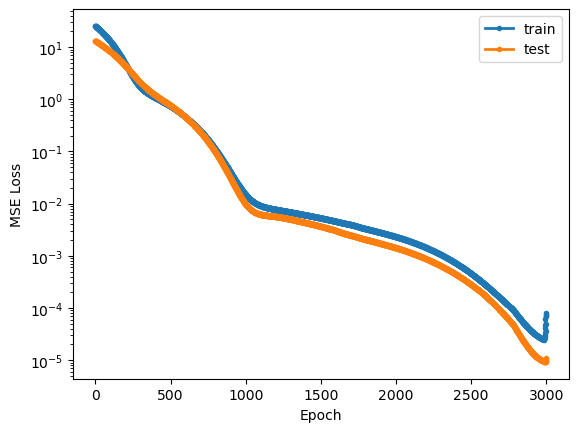

In [15]:
plot_losses(loss_dict["train"], loss_dict["test"])

### Use the model to predict the frequency and visualize the result

To visualize the learned behavior of the model, we plot the 1-contour of the learned function on top of the ground truth 1-contour. We do this using the validation set. 

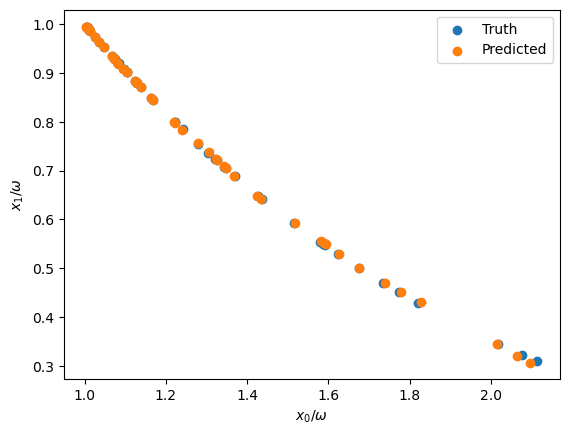

In [ ]:
with torch.no_grad():
    omega_pred = model(test_input)

plt.scatter(
    data_test_dim_hom.x0 / data_test_dim_hom.omega,
    data_test_dim_hom.x1 / data_test_dim_hom.omega,
    label="Truth",
)
plt.scatter(
    test_input[:, 0] / omega_pred[:, 0],
    test_input[:, 1] / omega_pred[:, 0],
    label="Predicted",
)
plt.xlabel("$x_0 / \omega$")
plt.ylabel("$x_1 / \omega$")
plt.legend()
plt.show()

In addition, we can directly plot the predicted values versus the ground truth. 

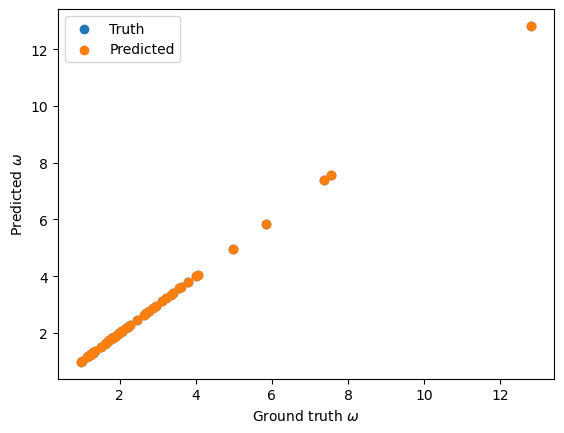

In [17]:
plt.scatter(data_test.omega, data_test.omega, label="Truth")
plt.scatter(omega_pred[:, 0], omega_pred[:, 0], label="Predicted")
plt.xlabel("Ground truth $\omega$")
plt.ylabel("Predicted $\omega$")
plt.legend()
plt.show()